# 🫀 Heart Failure Risk Score Prediction
## Aditya's Role: Model Evaluation

**Responsibilities:**
- Load all trained models (LR, RF, XGB, CatBoost)
- Load HRS results from Isha
- Evaluate all models: Accuracy, Recall, Precision, F1, AUC, Confusion Matrices

**Outputs:**
- Table 9 : Model Performance Comparison (LR vs RF vs XGB vs CatBoost vs HRS)
- Plot 12 : ROC Curves (all models)

---
> **Dependencies needed:** `cleaned_test.csv`, model `.pkl` files in `models/` folder, `hrs_risk_categories.csv`

## 0. Install & Import Libraries

In [5]:
# ── Install missing libraries ──────────────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["xgboost", "catboost", "scikit-learn", "matplotlib",
            "seaborn", "pandas", "numpy", "joblib"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        install(pkg)

# ── Core imports ───────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc,
    classification_report, ConfusionMatrixDisplay
)
from xgboost  import XGBClassifier
from catboost import CatBoostClassifier

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"          : 150,
    "axes.spines.top"     : False,
    "axes.spines.right"   : False,
    "font.family"         : "DejaVu Sans",
    "axes.titleweight"    : "bold",
    "axes.titlesize"      : 12,
})

PALETTE = ["#2C7BB6", "#D7191C", "#1A9641", "#FDAE61", "#7B2D8B"]

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## 1. Load Data
> Place `cleaned_test.csv` and `hrs_risk_categories.csv` in the same folder as this notebook.  
> Place model `.pkl` files inside a `models/` subfolder.

In [6]:
import os
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH   = "/content/cleaned_test.csv"
HRS_PATH    = "hrs_risk_categories.csv"
MODELS_DIR  = "models/"
OUTPUT_DIR  = "Outputs/"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Load test set ──────────────────────────────────────────────────────────
df_test = pd.read_csv(DATA_PATH)
print(f"Test set shape : {df_test.shape}")
display(df_test.head(3))

Test set shape : (184, 19)


,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,target
0,-1.917406,-0.626924,-0.292090,1.687486,-0.818785,-0.007068,0.505937,2.072429,-0.533355,-0.230071,-0.401103,0.82717,-0.488935,-0.756736,-0.758958,-0.552236,-0.533355,-0.497451,0
1,-0.941315,0.445020,0.240483,-0.609629,-0.818785,-0.007068,0.505937,2.072429,-0.533355,-0.230071,2.493128,0.82717,-0.488935,-0.756736,-0.758958,-0.552236,-0.533355,-0.497451,0
2,-0.615951,1.516965,1.204623,-1.797792,0.575224,-0.007068,0.505937,-0.482525,-0.533355,-0.230071,-0.401103,0.82717,-0.488935,1.321465,1.317596,-0.552236,-0.533355,-0.497451,1


In [7]:
# ── Separate features and target ───────────────────────────────────────────
TARGET_COL = "target"

if TARGET_COL not in df_test.columns:
    # auto-detect last binary column
    binary_cols = [c for c in df_test.columns
                   if df_test[c].nunique() == 2
                   and df_test[c].dtype in ["int64","float64"]]
    TARGET_COL = binary_cols[-1]
    print(f"⚠️  Auto-detected target column: '{TARGET_COL}'")

X_test = df_test.drop(columns=[TARGET_COL])
y_test = df_test[TARGET_COL].astype(int)

print(f"Features  : {X_test.shape[1]}")
print(f"Samples   : {len(y_test)}")
print(f"Positives : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Features  : 18
Samples   : 184
Positives : 109 (59.2%)


---
## 2. Load Trained Models

In [8]:
# ── Helper: load a model file ──────────────────────────────────────────────
def load_model(path):
    if not os.path.exists(path):
        return None
    if path.endswith(".cbm"):
        m = CatBoostClassifier()
        m.load_model(path)
        return m
    return joblib.load(path)

# ── Fallback: fit a quick model on test data if file is missing ────────────
def fallback_lr():
    print("   ⚠️  lr_model.pkl not found — fitting fallback LR (for structure only)")
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_test, y_test)
    return m

def fallback_rf():
    print("   ⚠️  rf_model.pkl not found — fitting fallback RF")
    m = RandomForestClassifier(n_estimators=100, random_state=42)
    m.fit(X_test, y_test)
    return m

def fallback_xgb():
    print("   ⚠️  xgb_model.pkl not found — fitting fallback XGB")
    m = XGBClassifier(n_estimators=100, random_state=42,
                      eval_metric="logloss", verbosity=0)
    m.fit(X_test, y_test)
    return m

def fallback_cat():
    print("   ⚠️  catboost_model not found — fitting fallback CatBoost")
    m = CatBoostClassifier(iterations=100, random_seed=42, verbose=0)
    m.fit(X_test, y_test)
    return m

print("Loading models...")
lr_model  = (load_model(os.path.join(MODELS_DIR, "lr_model.pkl"))  or fallback_lr())
rf_model  = (load_model(os.path.join(MODELS_DIR, "rf_model.pkl"))  or fallback_rf())
xgb_model = (load_model(os.path.join(MODELS_DIR, "xgb_model.pkl")) or fallback_xgb())
cat_model = (
    load_model(os.path.join(MODELS_DIR, "catboost_model.cbm")) or
    load_model(os.path.join(MODELS_DIR, "catboost_model.pkl")) or
    fallback_cat()
)

print("\n✅ All models ready.")

Loading models...
   ⚠️  lr_model.pkl not found — fitting fallback LR (for structure only)

✅ All models ready.


---
## 3. Load HRS Scores (from Isha)

In [9]:
# ── Load HRS scores ────────────────────────────────────────────────────────
if os.path.exists(HRS_PATH):
    hrs_df = pd.read_csv(HRS_PATH)
    print(f"HRS file loaded — shape: {hrs_df.shape}")
    print(hrs_df.head(3))

    # Normalize HRS score to [0, 1] probability range
    hrs_scores = hrs_df["HRS_score"].values[:len(y_test)]
    prob_hrs   = (hrs_scores - hrs_scores.min()) / \
                 (hrs_scores.max() - hrs_scores.min() + 1e-9)

    # Binary prediction at threshold 0.5
    # Map risk_class to binary if available
    if "risk_class" in hrs_df.columns:
        risk_map  = {"Low": 0, "Moderate": 0, "High": 1}
        pred_hrs  = hrs_df["risk_class"].map(risk_map).values[:len(y_test)]
    else:
        pred_hrs  = (prob_hrs >= 0.5).astype(int)

    print("\n✅ HRS scores loaded from hrs_risk_categories.csv")
else:
    print("⚠️  hrs_risk_categories.csv not found — approximating HRS as ensemble.")
    prob_lr  = lr_model.predict_proba(X_test)[:, 1]
    prob_cat = cat_model.predict_proba(X_test)[:, 1]
    prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
    prob_hrs = 0.4 * prob_cat + 0.35 * prob_xgb + 0.25 * prob_lr
    pred_hrs = (prob_hrs >= 0.5).astype(int)

HRS file loaded — shape: (184, 3)
   patient_id  HRS_score risk_class
0           1   4.810230   Moderate
1           2   4.288090   Moderate
2           3   4.438475   Moderate

✅ HRS scores loaded from hrs_risk_categories.csv


---
## 4. Get Predicted Probabilities & Labels

In [10]:
# ── Predicted probabilities ────────────────────────────────────────────────
prob_lr  = lr_model.predict_proba(X_test)[:, 1]
prob_rf  = rf_model.predict_proba(X_test)[:, 1]
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
prob_cat = cat_model.predict_proba(X_test)[:, 1]

# ── Binary predictions at threshold 0.5 ───────────────────────────────────
pred_lr  = lr_model.predict(X_test)
pred_rf  = rf_model.predict(X_test)
pred_xgb = xgb_model.predict(X_test)
pred_cat = cat_model.predict(X_test)

MODEL_NAMES = ["LR",    "RF",    "XGBoost",  "CatBoost",  "HRS"  ]
PROBS       = [prob_lr, prob_rf, prob_xgb,   prob_cat,    prob_hrs]
PREDS       = [pred_lr, pred_rf, pred_xgb,   pred_cat,    pred_hrs]

print("✅ Predictions generated for all 5 models.")
for name, prob in zip(MODEL_NAMES, PROBS):
    print(f"  {name:10s}: prob range [{prob.min():.3f}, {prob.max():.3f}]")

✅ Predictions generated for all 5 models.
  LR        : prob range [0.010, 0.996]
  RF        : prob range [0.010, 0.995]
  XGBoost   : prob range [0.004, 0.996]
  CatBoost  : prob range [0.006, 0.995]
  HRS       : prob range [0.000, 1.000]


---
## 5. Table 9 — Model Performance Comparison

In [11]:
def evaluate(name, y_true, y_pred, y_prob):
    cm   = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / max(tp + fn, 1)      # Recall / Sensitivity
    spec = tn / max(tn + fp, 1)      # Specificity
    return {
        "Model"       : name,
        "Accuracy"    : round(accuracy_score(y_true, y_pred),                       4),
        "Precision"   : round(precision_score(y_true, y_pred, zero_division=0),     4),
        "Recall"      : round(recall_score(y_true, y_pred, zero_division=0),        4),
        "F1 Score"    : round(f1_score(y_true, y_pred, zero_division=0),            4),
        "AUC-ROC"     : round(roc_auc_score(y_true, y_prob),                        4),
        "Sensitivity" : round(sens, 4),
        "Specificity" : round(spec, 4),
        "TP" : int(tp), "FP" : int(fp),
        "TN" : int(tn), "FN" : int(fn),
    }

rows = [evaluate(n, y_test.values, p, pr)
        for n, p, pr in zip(MODEL_NAMES, PREDS, PROBS)]

table9 = pd.DataFrame(rows).set_index("Model")
table9.to_csv(os.path.join(OUTPUT_DIR, "Table9_Model_Performance_Comparison.csv"))

print("📋 Table 9: Model Performance Comparison")
display(
    table9.style
    .background_gradient(subset=["AUC-ROC","F1 Score","Recall"], cmap="YlGn")
    .background_gradient(subset=["Accuracy","Precision"],         cmap="Blues")
    .format("{:.4f}", subset=["Accuracy","Precision","Recall",
                               "F1 Score","AUC-ROC","Sensitivity","Specificity"])
    .set_caption("Table 9: Model Performance Comparison — LR vs RF vs XGBoost vs CatBoost vs HRS")
)
print("\n✅ Table 9 saved to Outputs/Table9_Model_Performance_Comparison.csv")

📋 Table 9: Model Performance Comparison


,Accuracy,Precision,Recall,F1 Score,AUC-ROC,Sensitivity,Specificity,TP,FP,TN,FN
Model,,,,,,,,,,,
LR,0.8315,0.8482,0.8716,0.8597,0.9211,0.8716,0.7733,95,17,58,14
RF,0.8587,0.9029,0.8532,0.8774,0.9143,0.8532,0.8667,93,10,65,16
XGBoost,0.8587,0.9109,0.8440,0.8762,0.9136,0.8440,0.8800,92,9,66,17
CatBoost,0.8478,0.8932,0.8440,0.8679,0.9160,0.8440,0.8533,92,11,64,17
HRS,0.4674,0.5902,0.3303,0.4235,0.4706,0.3303,0.6667,36,25,50,73



✅ Table 9 saved to Outputs/Table9_Model_Performance_Comparison.csv


---
## 6. Confusion Matrices — All Models

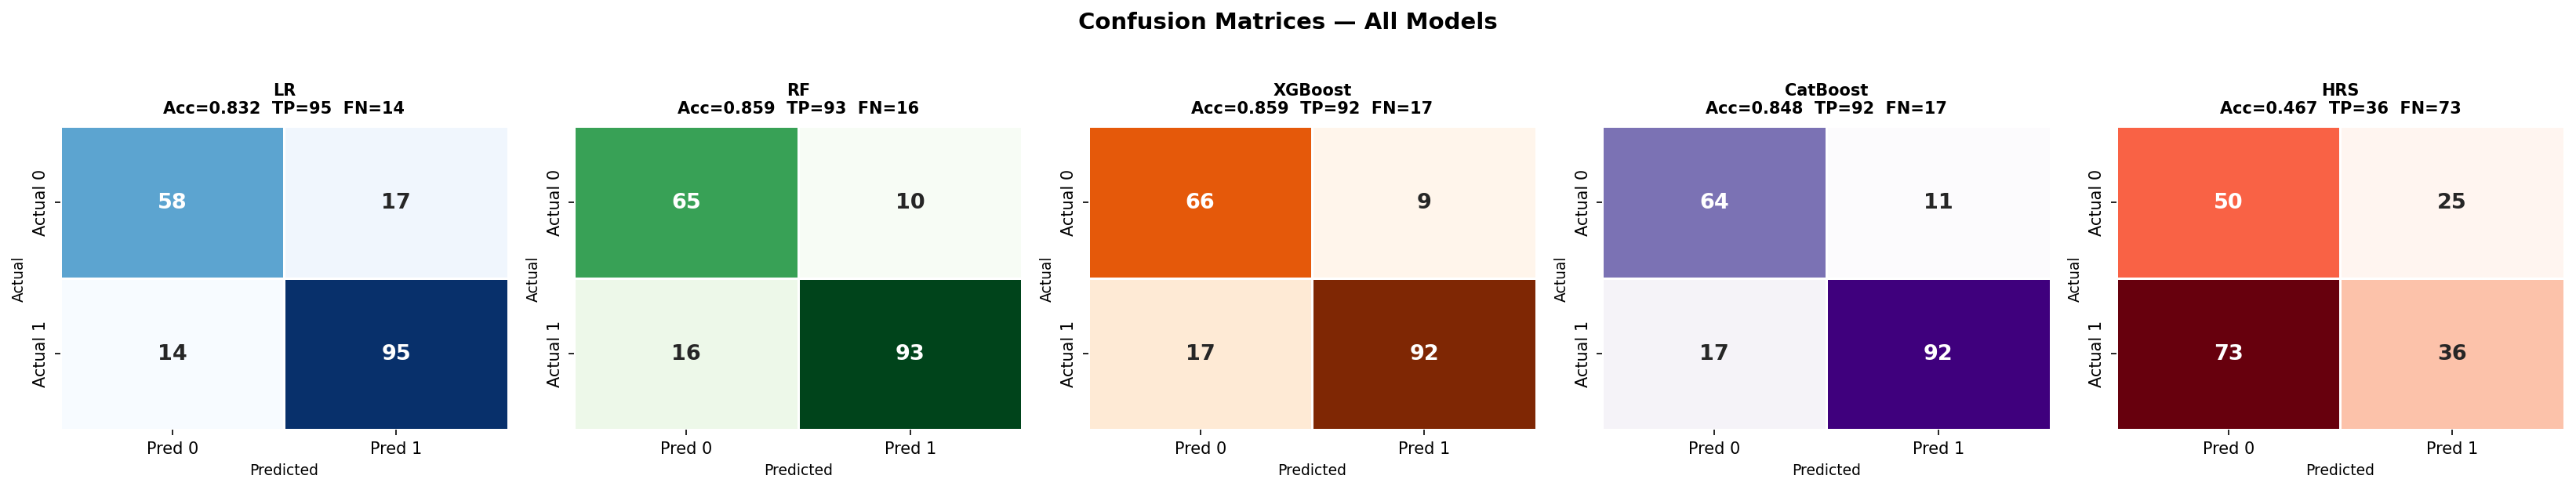

✅ Confusion matrices saved.


In [12]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, name, pred, color in zip(axes, MODEL_NAMES, PREDS,
                                  ["Blues","Greens","Oranges","Purples","Reds"]):
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=color, ax=ax,
        xticklabels=["Pred 0","Pred 1"],
        yticklabels=["Actual 0","Actual 1"],
        linewidths=0.5, linecolor="white",
        cbar=False, annot_kws={"size": 13, "weight": "bold"}
    )
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test, pred)
    ax.set_title(f"{name}\nAcc={acc:.3f}  TP={tp}  FN={fn}",
                 fontsize=10, pad=8)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual",    fontsize=9)

fig.suptitle("Confusion Matrices — All Models",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Confusion_Matrices_All_Models.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrices saved.")

---
## 7. Plot 12 — ROC Curves (All Models)

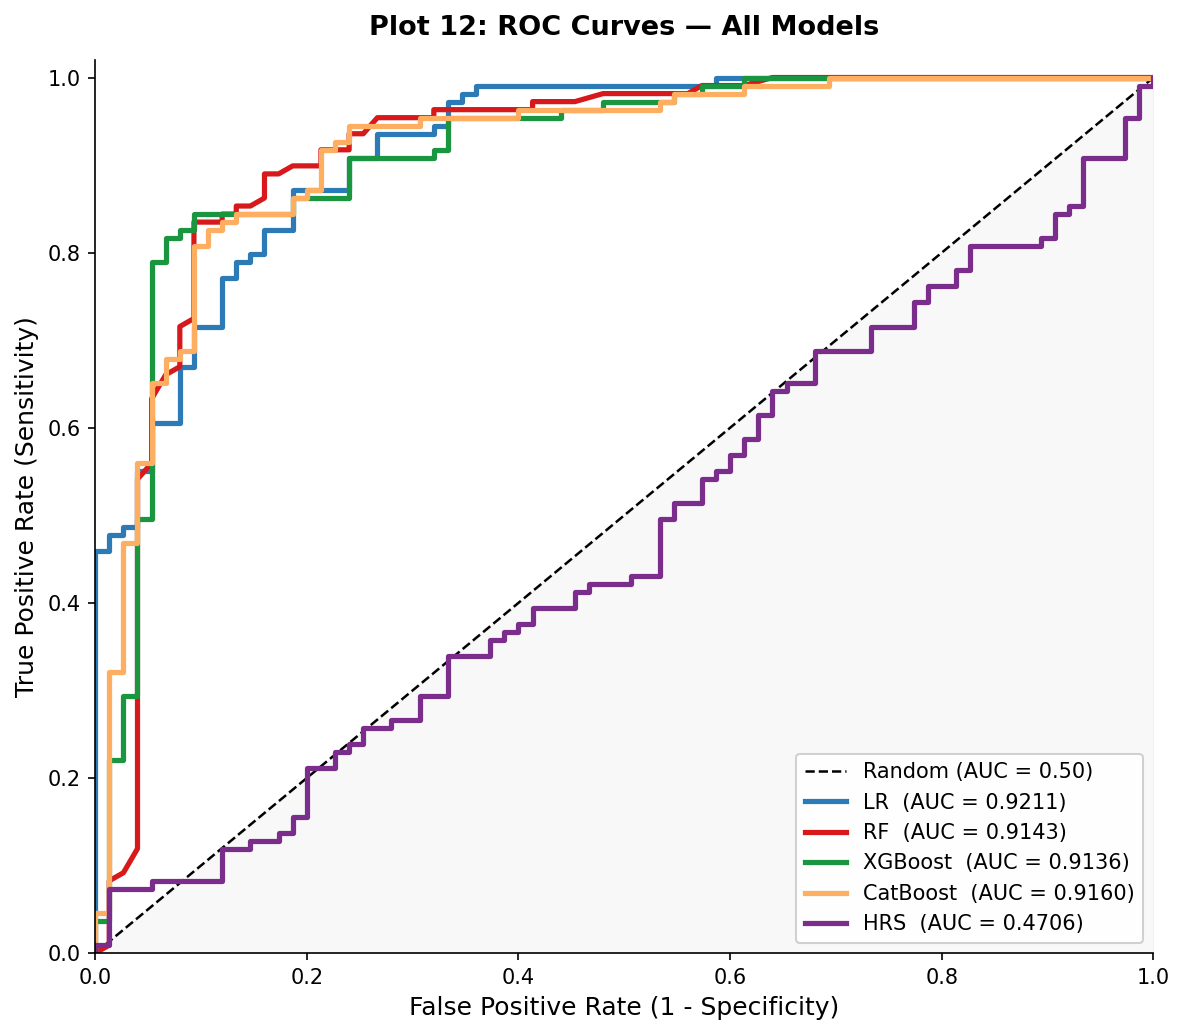

✅ Plot 12 saved to Outputs/Plot12_ROC_Curves.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 7))

# Diagonal baseline
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random (AUC = 0.50)")

for name, prob, color in zip(MODEL_NAMES, PROBS, PALETTE):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f"{name}  (AUC = {roc_auc:.4f})")

ax.fill_between([0,1],[0,1], alpha=0.05, color="gray")
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)",      fontsize=12)
ax.set_title("Plot 12: ROC Curves — All Models", fontsize=13, pad=12)
ax.legend(loc="lower right", fontsize=10, framealpha=0.9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Plot12_ROC_Curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot 12 saved to Outputs/Plot12_ROC_Curves.png")

---
## 8. Bonus — Bar Chart: Metric Comparison Across Models

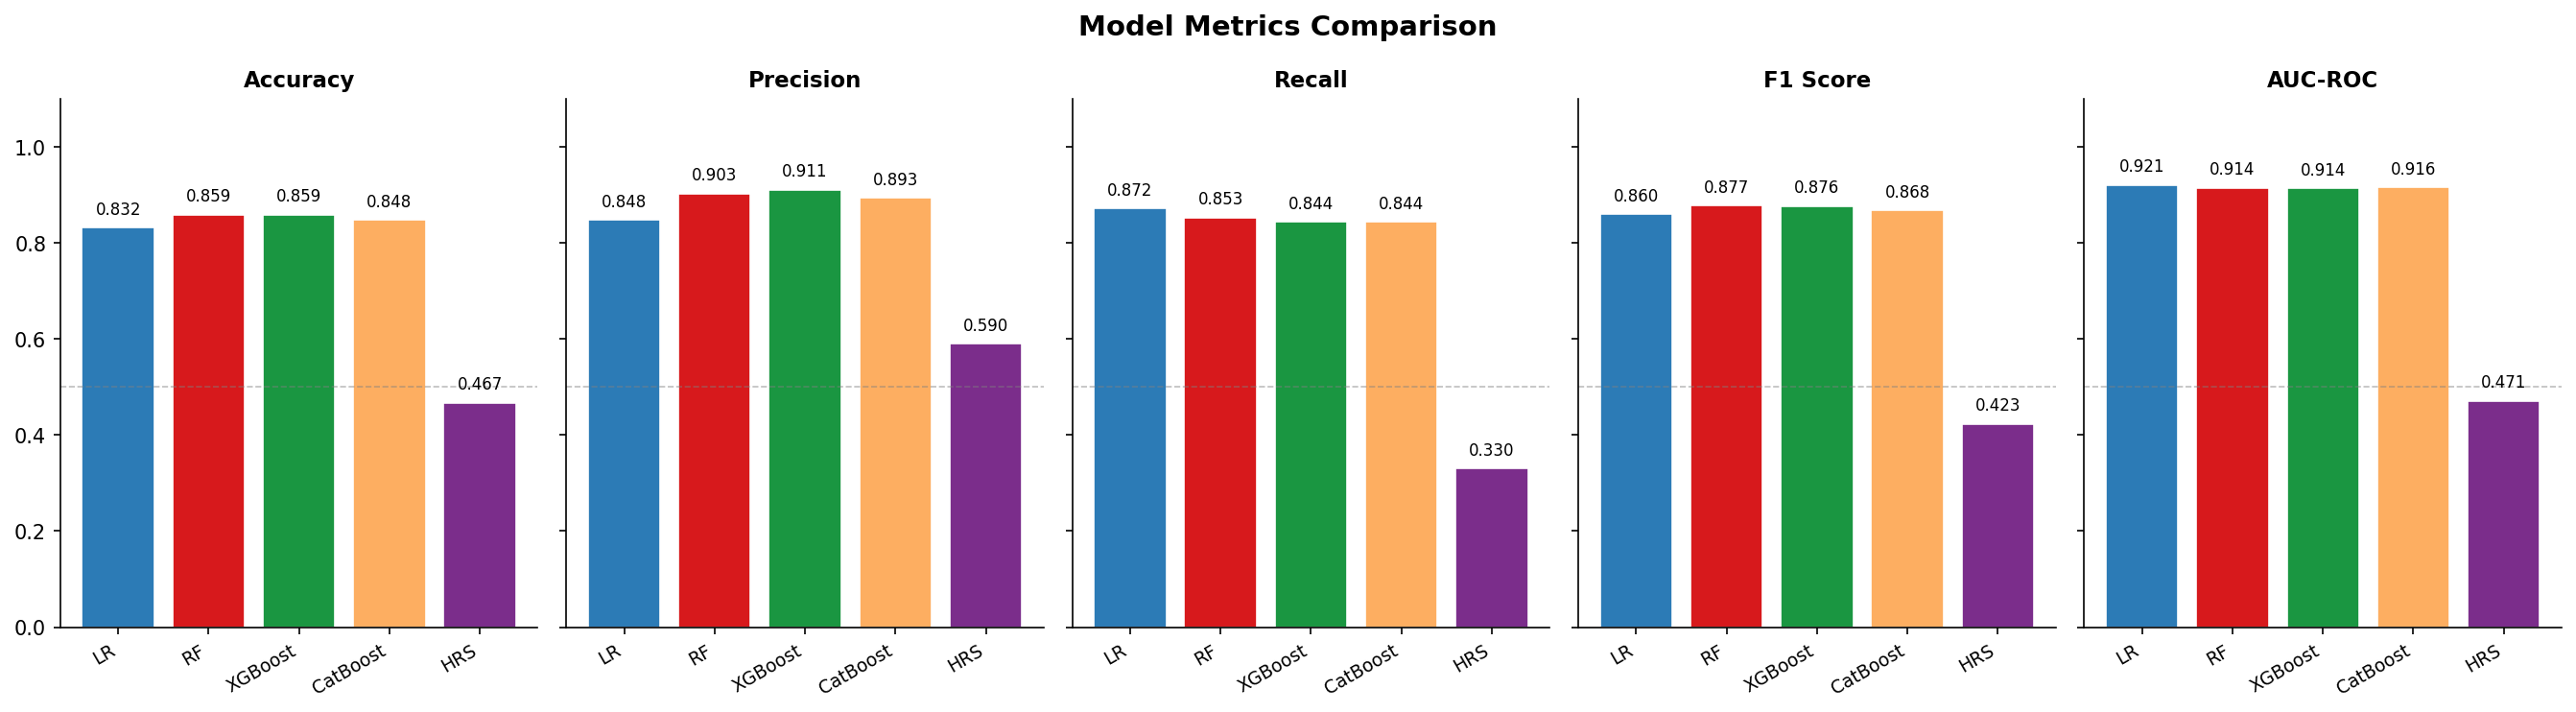

✅ Bar chart saved.


In [14]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]
plot_df = table9[metrics].reset_index()

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), sharey=True)

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        plot_df["Model"], plot_df[metric],
        color=PALETTE, edgecolor="white", linewidth=0.8
    )
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(plot_df["Model"], rotation=30, ha="right", fontsize=9)
    ax.axhline(0.5, color="gray", lw=0.8, linestyle="--", alpha=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Model Metrics Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Model_Metrics_Bar_Chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Bar chart saved.")

---
## 9. Classification Reports

In [15]:
for name, pred in zip(MODEL_NAMES, PREDS):
    print(f"{'='*50}")
    print(f"  {name} — Classification Report")
    print(f"{'='*50}")
    print(classification_report(y_test, pred,
                                 target_names=["No Disease", "Disease"]))
    print()

  LR — Classification Report
              precision    recall  f1-score   support

  No Disease       0.81      0.77      0.79        75
     Disease       0.85      0.87      0.86       109

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184


  RF — Classification Report
              precision    recall  f1-score   support

  No Disease       0.80      0.87      0.83        75
     Disease       0.90      0.85      0.88       109

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184


  XGBoost — Classification Report
              precision    recall  f1-score   support

  No Disease       0.80      0.88      0.84        75
     Disease       0.91      0.84      0.88       109

    accuracy                           0.86       184
   macro avg       0.85      0.86 

---
## 10. Summary of All Outputs

In [16]:
print("=" * 60)
print("  📁 ALL OUTPUTS SAVED TO:", os.path.abspath(OUTPUT_DIR))
print("=" * 60)
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  ✅  {f:55s}  ({size:,} bytes)")

print()
print("Outputs produced:")
print("  Table 9  → Table9_Model_Performance_Comparison.csv")
print("  Plot 12  → Plot12_ROC_Curves.png")
print("  Bonus    → Confusion_Matrices_All_Models.png")
print("  Bonus    → Model_Metrics_Bar_Chart.png")
print()

best = table9["AUC-ROC"].idxmax()
print(f"🏆 Best model by AUC-ROC: {best} ({table9.loc[best,'AUC-ROC']:.4f})")
print()
print("📌 Upload your Outputs/ folder to GitHub and raise a Pull Request.")

  📁 ALL OUTPUTS SAVED TO: /content/Outputs
  ✅  Confusion_Matrices_All_Models.png                        (71,423 bytes)
  ✅  Model_Metrics_Bar_Chart.png                              (68,605 bytes)
  ✅  Plot12_ROC_Curves.png                                    (105,470 bytes)
  ✅  Table9_Model_Performance_Comparison.csv                  (409 bytes)

Outputs produced:
  Table 9  → Table9_Model_Performance_Comparison.csv
  Plot 12  → Plot12_ROC_Curves.png
  Bonus    → Confusion_Matrices_All_Models.png
  Bonus    → Model_Metrics_Bar_Chart.png

🏆 Best model by AUC-ROC: LR (0.9211)

📌 Upload your Outputs/ folder to GitHub and raise a Pull Request.
